# 14 — SHAP Explainability of the Final Model

This notebook applies SHAP (SHapley Additive exPlanations) to the final model selected during the evaluation stage.

The selected model is the **Full Multimodal XGBoost**, which achieved the strongest overall performance during model evaluation and was therefore selected as the final model for interpretation.

The objectives of this notebook are to:

- Generate global SHAP explanations.
- Identify the most influential predictors.
- Compare feature importance across data modalities.
- Analyze feature contributions across neurological tasks.
- Evaluate the relative importance of sensor types.
- Compare contributions between the left and right wrists.
- Examine the importance of questionnaire-derived features.
- Produce participant-level explanations for individual predictions.

The notebook uses the saved fitted Week 5 pipeline and generates post-hoc explanations without retraining or modifying the final model.

In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd

import shap
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns",100)
pd.set_option("display.max_rows",100)

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if not (PROJECT_ROOT/"src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT/"data"/"processed"
MODELS_DIR = PROJECT_ROOT/"models"

OUTPUTS_DIR = PROJECT_ROOT/"outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"

METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)
SHAP_DIR = OUTPUTS_DIR / "shap"

SHAP_FIGURES = SHAP_DIR / "figures"
SHAP_TABLES = SHAP_DIR / "tables"

SHAP_FIGURES.mkdir(parents=True, exist_ok=True)
SHAP_TABLES.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = OUTPUTS_DIR/"figures"
TABLES_DIR = OUTPUTS_DIR/"tables"

FIGURES_DIR.mkdir(exist_ok=True,parents=True)
TABLES_DIR.mkdir(exist_ok=True,parents=True)

## Load Final Model

The explainability analysis is performed using the final model selected after validation and test evaluation.

Model:
- Full Multimodal
- XGBoost

In [3]:
MODEL_PATH = MODELS_DIR/"full_multimodal_xgboost.joblib"

pipeline = joblib.load(MODEL_PATH)

pipeline.named_steps

{'preprocessing': ColumnTransformer(transformers=[('numerical',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', StandardScaler())]),
                                  ['CrossArms_Left_AccX_Mean',
                                   'CrossArms_Right_AccX_Mean',
                                   'DrinkGlas_Left_AccX_Mean',
                                   'DrinkGlas_Right_AccX_Mean',
                                   'Entrainment_Left_AccX_Mean',
                                   'Entrainment_Right_AccX_Mean',
                                   'HoldWeight_Left_AccX_Mean',
                                   'HoldWeight_Righ...
                                   'Entrainment_Right_AccX_Median',
                                   'HoldWeight_Left_AccX_Median',
                                   'HoldWeight_Right_AccX_Median', .

## Load Held-Out Test Dataset

SHAP explanations are generated using the unseen held-out test set in order to explain the predictions of the final deployed model.

In [4]:
TEST_PATH = DATA_DIR/"test_multimodal_full_task_aware.csv"
test_df = pd.read_csv(TEST_PATH)
y_test = test_df["label"]
X_raw = test_df[pipeline.feature_names_in_]

## Recover the Final Feature Set

The final model was trained after preprocessing, variance filtering, and feature selection. Therefore, SHAP explanations are generated using the final selected predictors rather than the complete set of raw variables.

This ensures that the explanations are consistent with the exact feature space used by the final predictive model and accurately reflect the variables that contributed to its predictions.

In [5]:
preprocessor = pipeline.named_steps["preprocessing"]
feature_names = preprocessor.get_feature_names_out()
variance = pipeline.named_steps["variance_filter"]
feature_after_variance = feature_names[
    variance.get_support()
]
selector = pipeline.named_steps["feature_selection"]
selected_features = feature_after_variance[
    selector.get_support()
]
selected_features = pd.Series(selected_features,name="Selected Feature")
print(f"Selected features: {len(selected_features)}")
display(selected_features.to_frame())

Selected features: 500


,Selected Feature
0,numerical__CrossArms_Right_AccX_Mean
1,numerical__TouchIndex_Right_AccX_Mean
2,numerical__PointFinger_Left_AccX_Median
3,numerical__TouchIndex_Right_AccX_Median
4,numerical__HoldWeight_Left_AccX_Std
...,...
495,numerical__weight_kg
496,categorical__gender_Female
497,categorical__gender_Male
498,categorical__family_history_first_degree_No


## Transform the Test Data

The test dataset is transformed using the fitted preprocessing pipeline obtained during model training. All preprocessing operations, including encoding, scaling, and feature selection, are applied exactly as learned from the training data.

No preprocessing step is refitted, ensuring that the evaluation and SHAP explanations are generated under the same conditions as the final deployed model.

In [6]:
X_processed = pipeline.named_steps["preprocessing"].transform(X_raw)
X_processed = pipeline.named_steps["variance_filter"].transform(X_processed)
X_processed = pipeline.named_steps["feature_selection"].transform(X_processed)
X_processed = pd.DataFrame(
    X_processed,
    columns=selected_features
)
X_processed.head()

Selected Feature,numerical__CrossArms_Right_AccX_Mean,numerical__TouchIndex_Right_AccX_Mean,numerical__PointFinger_Left_AccX_Median,numerical__TouchIndex_Right_AccX_Median,numerical__HoldWeight_Left_AccX_Std,numerical__LiftHold_Left_AccX_Std,numerical__StretchHold_Left_AccX_Std,numerical__CrossArms_Left_AccX_IQR,numerical__CrossArms_Right_AccX_IQR,numerical__DrinkGlas_Left_AccX_IQR,numerical__DrinkGlas_Right_AccX_IQR,numerical__HoldWeight_Left_AccX_IQR,numerical__LiftHold_Left_AccX_IQR,numerical__LiftHold_Right_AccX_IQR,numerical__PointFinger_Left_AccX_IQR,numerical__PointFinger_Right_AccX_IQR,numerical__StretchHold_Left_AccX_IQR,numerical__TouchNose_Left_AccX_IQR,numerical__TouchNose_Right_AccX_IQR,numerical__HoldWeight_Left_AccX_RMS,numerical__LiftHold_Left_AccX_RMS,numerical__StretchHold_Left_AccX_RMS,numerical__Entrainment_Left_AccY_Median,numerical__LiftHold_Left_AccY_Std,numerical__LiftHold_Right_AccY_Std,numerical__StretchHold_Left_AccY_Std,numerical__LiftHold_Right_AccY_Min,numerical__TouchIndex_Right_AccY_Min,numerical__LiftHold_Left_AccY_Max,numerical__CrossArms_Left_AccY_IQR,numerical__CrossArms_Right_AccY_IQR,numerical__DrinkGlas_Left_AccY_IQR,numerical__DrinkGlas_Right_AccY_IQR,numerical__HoldWeight_Left_AccY_IQR,numerical__HoldWeight_Right_AccY_IQR,numerical__LiftHold_Left_AccY_IQR,numerical__LiftHold_Right_AccY_IQR,numerical__StretchHold_Left_AccY_IQR,numerical__LiftHold_Left_AccY_RMS,numerical__LiftHold_Right_AccY_RMS,numerical__StretchHold_Left_AccY_RMS,numerical__StretchHold_Right_AccZ_Mean,numerical__PointFinger_Left_AccZ_Median,numerical__PointFinger_Right_AccZ_Median,numerical__TouchIndex_Left_AccZ_Median,numerical__TouchNose_Left_AccZ_Median,numerical__TouchNose_Right_AccZ_Median,numerical__DrinkGlas_Left_AccZ_Std,numerical__HoldWeight_Left_AccZ_Std,numerical__LiftHold_Left_AccZ_Std,...,numerical__TouchNose_RightWrist_gyro_magnitude_dominant_frequency,numerical__TouchNose_RightWrist_gyro_magnitude_spectral_centroid,numerical__TouchNose_RightWrist_gyro_magnitude_spectral_entropy,numerical__TouchNose_RightWrist_gyro_magnitude_spectral_power,numerical__TouchNose_RightWrist_gyro_x_spectral_entropy,numerical__TouchNose_RightWrist_gyro_y_dominant_frequency,numerical__TouchNose_RightWrist_gyro_y_spectral_centroid,numerical__TouchNose_RightWrist_gyro_y_spectral_power,numerical__TouchNose_RightWrist_gyro_z_spectral_entropy,numerical__PointFinger_Gyro_Magnitude_Energy_difference,numerical__Q01,numerical__Q02,numerical__Q03,numerical__Q05,numerical__Q07,numerical__Q08,numerical__Q09,numerical__Q10,numerical__Q12,numerical__Q13,numerical__Q14,numerical__Q15,numerical__Q16,numerical__Q18,numerical__Q19,numerical__Q20,numerical__Q21,numerical__Q22,numerical__Q24,numerical__Q25,numerical__Q26,numerical__Q27,numerical__Q28,numerical__Q29,numerical__Q30,numerical__gastrointestinal_count,numerical__urinary_count,numerical__pain_count,numerical__miscellaneous_count,numerical__apathy_attention_memory_count,numerical__distortion_perception_count,numerical__sexual_function_count,numerical__cardiovascular_count,numerical__sleep_fatigue_count,numerical__height_cm,numerical__weight_kg,categorical__gender_Female,categorical__gender_Male,categorical__family_history_first_degree_No,categorical__alcohol_effect_on_tremor_Improvement
0,0.594623,0.784478,-1.354586,-1.061677,0.034718,2.904390,0.285979,0.542220,0.259951,0.582039,0.398666,0.376527,4.048594,1.820827,1.753691,1.337923,0.486154,0.392573,0.726662,0.034517,2.903495,0.285247,-0.406929,1.843606,0.518307,0.158010,-0.913936,0.148662,2.232418,0.366340,0.055296,0.612033,0.218409,-0.108663,-0.071675,2.150487,0.940460,0.268935,1.843380,0.518006,0.157882,0.344650,0.772586,-0.102434,0.253931,0.159716,-0.088506,0.858052,-0.071021,2.564897,...,0.867809,0.736190,-0.473362,0.745831,-0.966208,0.979853,0.516662,-0.007396,-0.685584,0.657409,-0.657506,-0.705491,1.417453,1.334039,1.690806,0.884652,-1.210853,-0.424094,-0.724970,-0.596131,-0.334461,-0.836350,1.467599,-0.511408,-0.614940,-0.720082,-

## Compute SHAP Values

TreeExplainer is used because the final predictive model is an **XGBoost classifier**, which belongs to the family of tree-based ensemble models. SHAP values are computed for all participants in the held-out test set to quantify the contribution of each selected feature to the multiclass predictions.

The resulting SHAP values provide both global and local explanations while preserving consistency with the fitted XGBoost model.

In [7]:
# Extract trained XGBoost classifier
classifier = pipeline.named_steps["classifier"]
print(classifier)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=3, ...)


In [8]:
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_processed)
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(71, 500, 3)


## Global Feature Importance
Mean absolute SHAP values are used to quantify the overall contribution of each predictor across all participants and diagnostic classes.

Ranking features according to their mean absolute SHAP values provides a global measure of importance, allowing the identification of the variables that most strongly influenced the final XGBoost model.


In [9]:
# Global SHAP importance
importance = np.abs(shap_values).mean(axis=(0, 2))
importance_df = (
    pd.DataFrame({
        "Feature": selected_features,
        "Mean |SHAP|": importance
    })
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
    .reset_index(drop=True)
)
display(importance_df)

,Feature,Mean |SHAP|
0,numerical__gastrointestinal_count,0.254065
1,numerical__StretchHold_Left_AccZ_IQR,0.173513
2,numerical__urinary_count,0.157888
3,numerical__distortion_perception_count,0.137186
4,numerical__Q25,0.119215
...,...,...
495,numerical__LiftHold_Left_AccX_RMS,0.000000
496,numerical__StretchHold_Left_AccX_RMS,0.000000
497,numerical__LiftHold_Left_AccY_Std,0.000000
498,numerical__StretchHold_Left_AccY_Std,0.000000


In [10]:
# Top 20 most important features
display(
    importance_df.head(20)
)

,Feature,Mean |SHAP|
0,numerical__gastrointestinal_count,0.254065
1,numerical__StretchHold_Left_AccZ_IQR,0.173513
2,numerical__urinary_count,0.157888
3,numerical__distortion_perception_count,0.137186
4,numerical__Q25,0.119215
5,numerical__RelaxedTask_LeftWrist_acc_magnitude...,0.107896
6,numerical__HoldWeight_RightWrist_gyro_y_domina...,0.092538
7,numerical__Q02,0.080700
8,numerical__PointFinger_RightWrist_acc_y_domina...,0.074772
9,numerical__HoldWeight_Left_GyroZ_IQR,0.073613


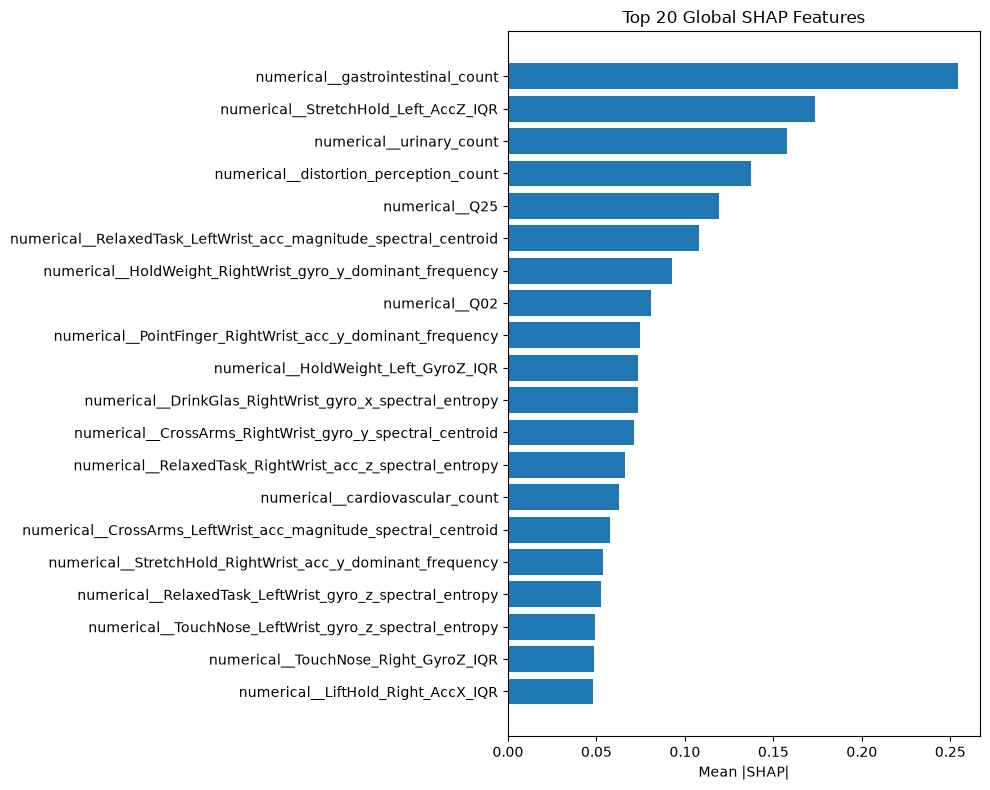

In [11]:
# Global SHAP bar plot
plt.figure(figsize=(10,8))
top20 = importance_df.head(20)
plt.barh(
    top20["Feature"][::-1],
    top20["Mean |SHAP|"][::-1]
)
plt.xlabel("Mean |SHAP|")
plt.title(
    "Top 20 Global SHAP Features"
)
plt.tight_layout()
plt.savefig(
    SHAP_FIGURES /
    "Top 20 Global SHAP Features.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Generating beeswarm for Healthy


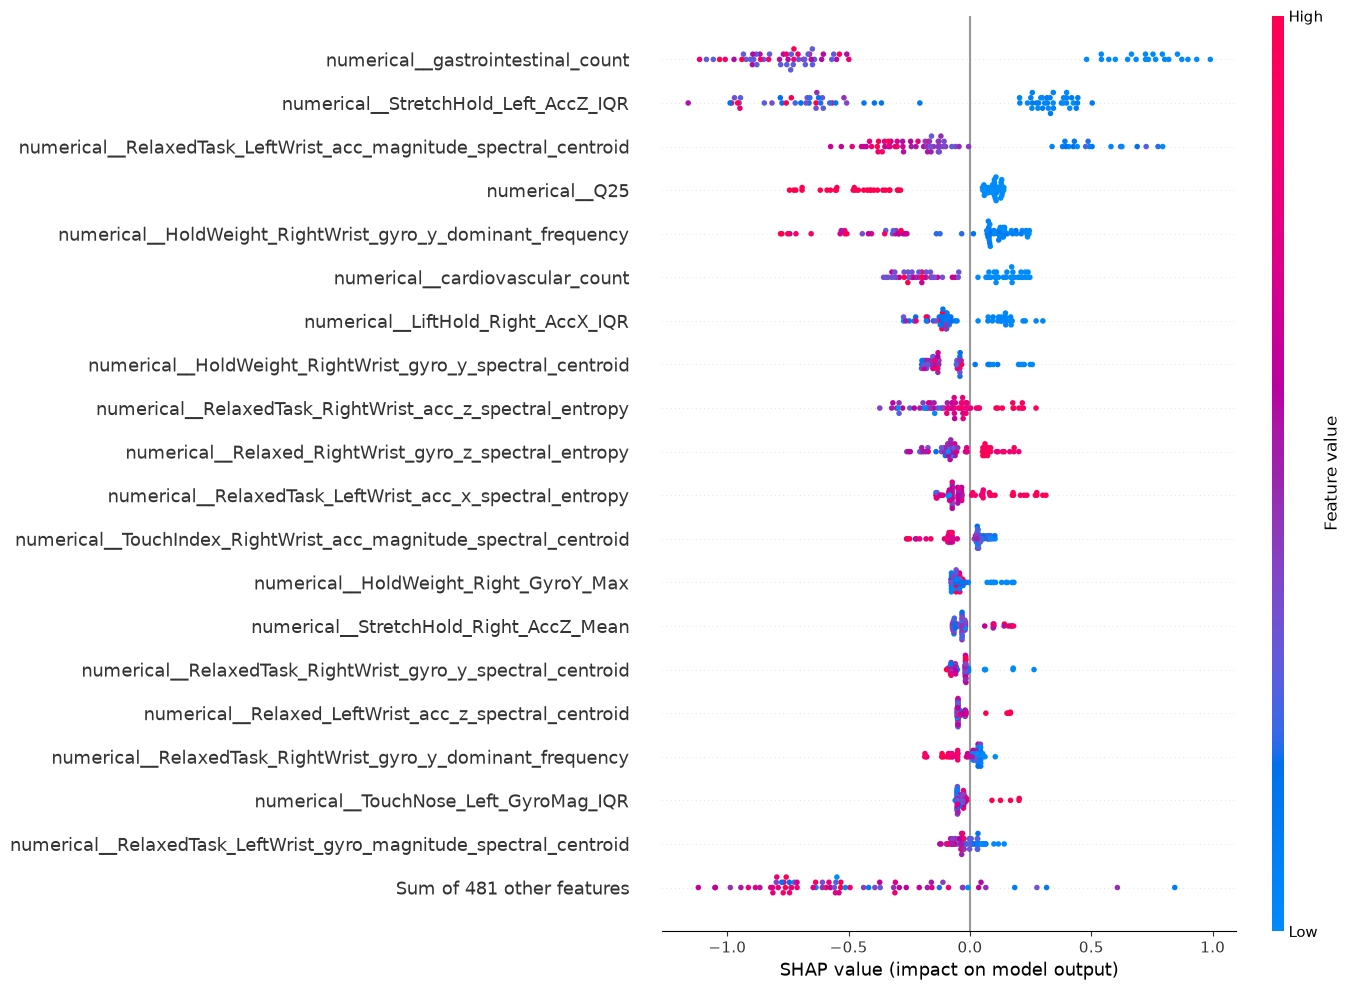

Generating beeswarm for Parkinsons_Disease


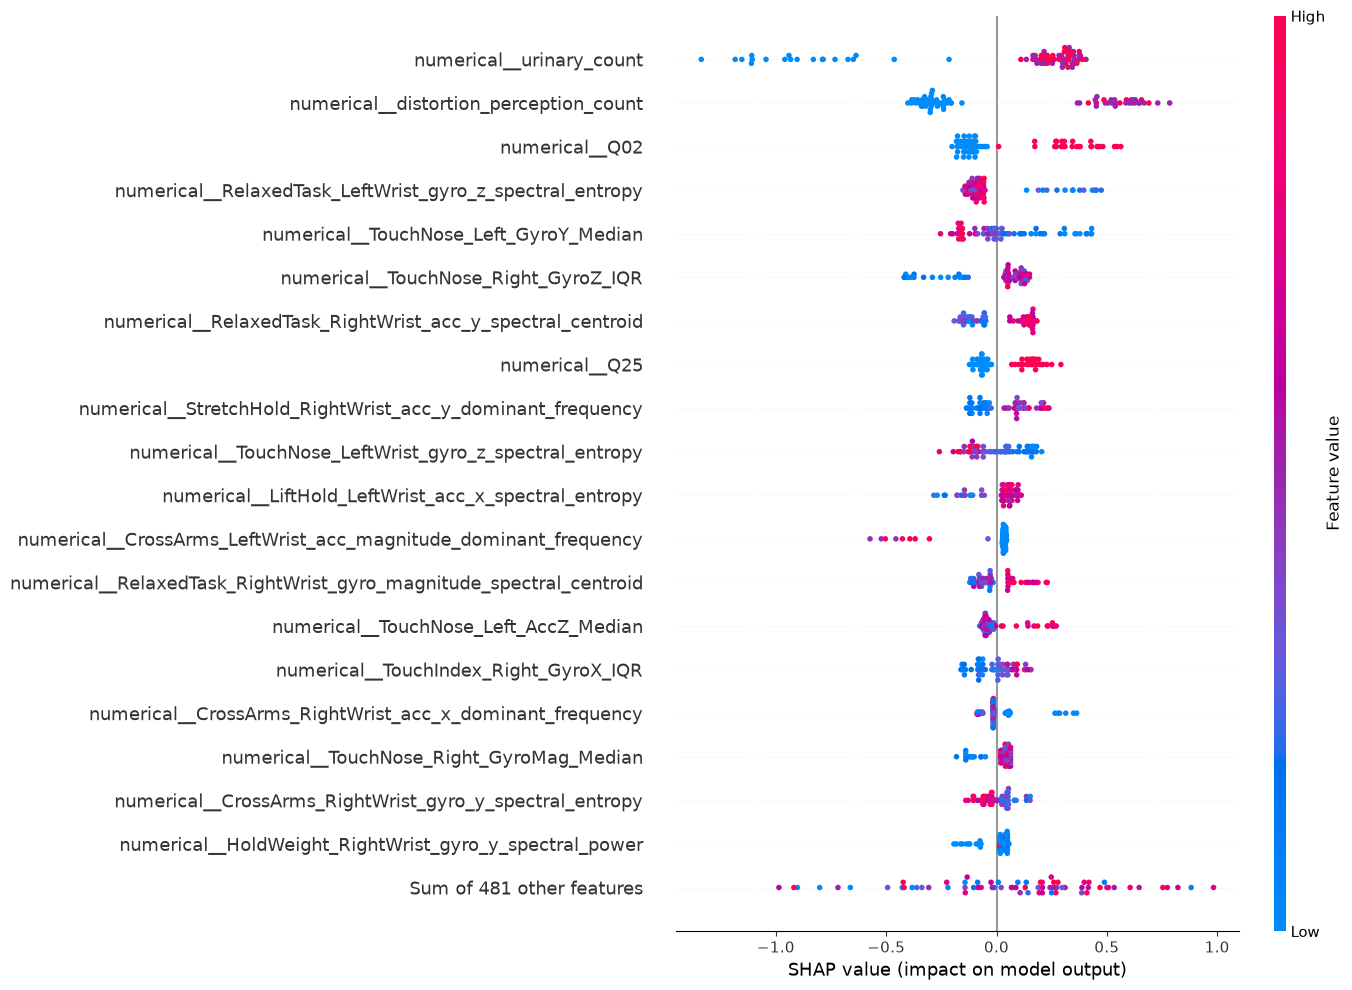

Generating beeswarm for Other_Movement_Disorders


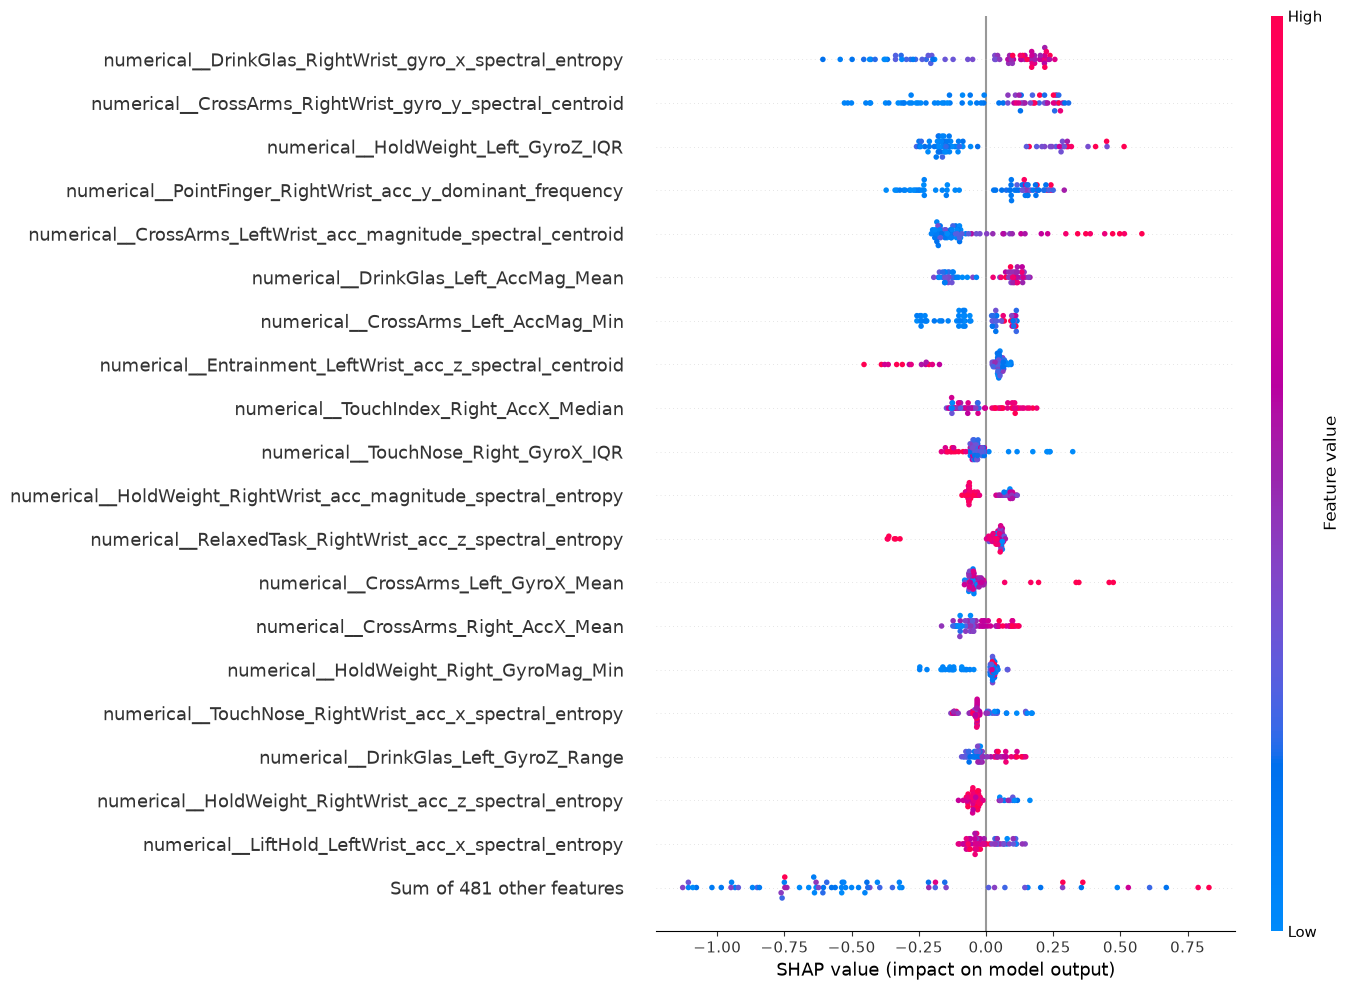

In [ ]:
# SHAP Beeswarm Plots (One per Class)
import matplotlib.pyplot as plt
import shap

CLASS_INFO = [
    (0, "Healthy"),
    (1, "Parkinsons_Disease"),
    (2, "Other_Movement_Disorders"),
]

for class_idx, class_name in CLASS_INFO:

    print("=" * 70)
    print(f"Generating beeswarm for {class_name}")

    explanation = shap.Explanation(
        values=shap_values[:, :, class_idx],
        base_values=np.repeat(
            explainer.expected_value[class_idx],
            X_processed.shape[0]
        ),
        data=X_processed.values,
        feature_names=selected_features,
    )

    shap.plots.beeswarm(
        explanation,
        max_display=20,
        show=False,
    )

    fig = plt.gcf()
    fig.set_size_inches(14, 10)

    plt.tight_layout()

    plt.savefig(
        SHAP_FIGURES / f"beeswarm_{class_name}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    plt.close(fig)

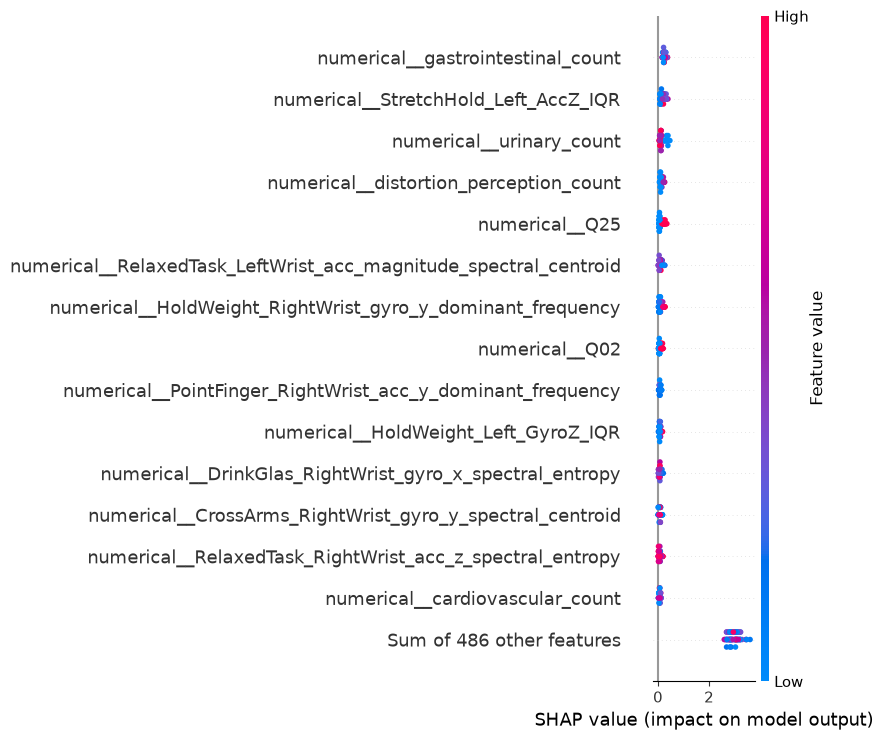

In [49]:
# Global SHAP beeswarm
mean_shap = np.mean(
    np.abs(shap_values),
    axis=2
)
explanation = shap.Explanation(
    values=mean_shap,
    data=X_processed.values,
    feature_names=selected_features
)
plt.figure(figsize=(12, 8))

shap.plots.beeswarm(
    explanation,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    SHAP_FIGURES / "shap_beeswarm_global.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# Save SHAP importance
importance_df.to_csv(
    SHAP_TABLES / "global_shap_importance.csv",
    index=False
)
print(
    "Saved:",
    SHAP_TABLES/ "global_shap_importance.csv"
)

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\global_shap_importance.csv


### Observation

Global SHAP analysis showed that the final **Full Multimodal XGBoost** model relied on a combination of questionnaire-derived variables and wearable sensor features to perform multiclass classification.

The most influential predictor was the aggregated **gastrointestinal symptom count**, followed by movement-derived features extracted from accelerometer signals during the Stretch Hold task, the aggregated **urinary symptom count**, the **distortion/perception symptom count**, and questionnaire item **Q25**. Additional high-ranking predictors included wearable features derived from multiple neurological tasks together with questionnaire variables such as **Q02** and the **cardiovascular symptom count**.

Overall, the SHAP results indicate that the model integrates complementary information from both clinical questionnaires and wearable sensor recordings. Rather than relying on a single dominant predictor, the final XGBoost model combines symptom-domain summaries with objective movement characteristics obtained during standardized neurological assessments, highlighting the value of a multimodal approach for Parkinson's disease screening.

## Class-Specific SHAP Analysis

Although global SHAP importance summarizes feature contributions across all diagnostic classes, multiclass classification benefits from examining the variables that are most influential for each individual class.

This section computes class-specific SHAP importance for:

- Healthy Controls (Class 0)
- Parkinson's Disease (Class 1)
- Other Movement Disorders (Class 2)

For each class, the mean absolute SHAP value is calculated across all participants to identify the predictors that contributed most strongly to that specific diagnostic category.

In [14]:
CLASS_NAMES = {
    0: "Healthy",
    1: "Parkinson's Disease",
    2: "Other Movement Disorders"
}

class_importance = {}

for class_idx in range(len(CLASS_NAMES)):
    importance = np.mean(
        np.abs(shap_values[:, :, class_idx]),
        axis=0
    )
    df = (
        pd.DataFrame({
            "Feature": selected_features,
            "Mean |SHAP|": importance
        })
        .sort_values(
            "Mean |SHAP|",
            ascending=False
        )
        .reset_index(drop=True)
    )
    class_importance[class_idx] = df
    print("\n")
    print("="*60)
    print(CLASS_NAMES[class_idx])
    display(df.head(15))



Healthy


,Feature,Mean |SHAP|
0,numerical__gastrointestinal_count,0.762196
1,numerical__StretchHold_Left_AccZ_IQR,0.520540
2,numerical__RelaxedTask_LeftWrist_acc_magnitude...,0.323688
3,numerical__Q25,0.251086
4,numerical__HoldWeight_RightWrist_gyro_y_domina...,0.250137
5,numerical__cardiovascular_count,0.186117
6,numerical__LiftHold_Right_AccX_IQR,0.136783
7,numerical__HoldWeight_RightWrist_gyro_y_spectr...,0.131141
8,numerical__RelaxedTask_RightWrist_acc_z_spectr...,0.129883
9,numerical__Relaxed_RightWrist_gyro_z_spectral_...,0.101852




Parkinson's Disease


,Feature,Mean |SHAP|
0,numerical__urinary_count,0.449369
1,numerical__distortion_perception_count,0.411558
2,numerical__Q02,0.212693
3,numerical__RelaxedTask_LeftWrist_gyro_z_spectr...,0.140916
4,numerical__TouchNose_Left_GyroY_Median,0.138491
5,numerical__TouchNose_Right_GyroZ_IQR,0.136933
6,numerical__RelaxedTask_RightWrist_acc_y_spectr...,0.123507
7,numerical__Q25,0.106559
8,numerical__StretchHold_RightWrist_acc_y_domina...,0.103437
9,numerical__TouchNose_LeftWrist_gyro_z_spectral...,0.103018




Other Movement Disorders


,Feature,Mean |SHAP|
0,numerical__DrinkGlas_RightWrist_gyro_x_spectra...,0.214671
1,numerical__CrossArms_RightWrist_gyro_y_spectra...,0.213146
2,numerical__HoldWeight_Left_GyroZ_IQR,0.201582
3,numerical__PointFinger_RightWrist_acc_y_domina...,0.184699
4,numerical__CrossArms_LeftWrist_acc_magnitude_s...,0.169204
5,numerical__DrinkGlas_Left_AccMag_Mean,0.119997
6,numerical__CrossArms_Left_AccMag_Min,0.108140
7,numerical__Entrainment_LeftWrist_acc_z_spectra...,0.099269
8,numerical__TouchIndex_Right_AccX_Median,0.088331
9,numerical__TouchNose_Right_GyroX_IQR,0.072384


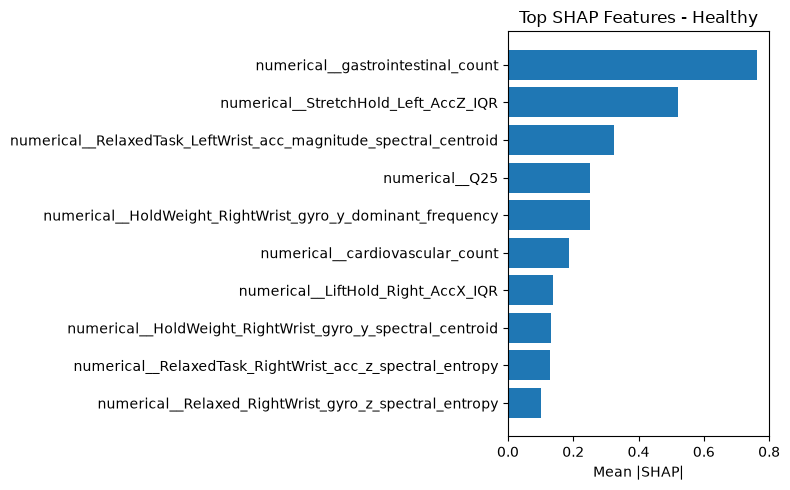

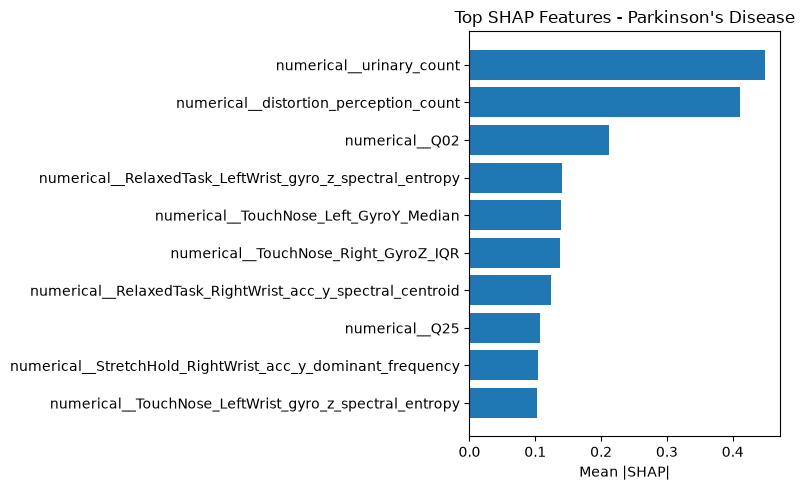

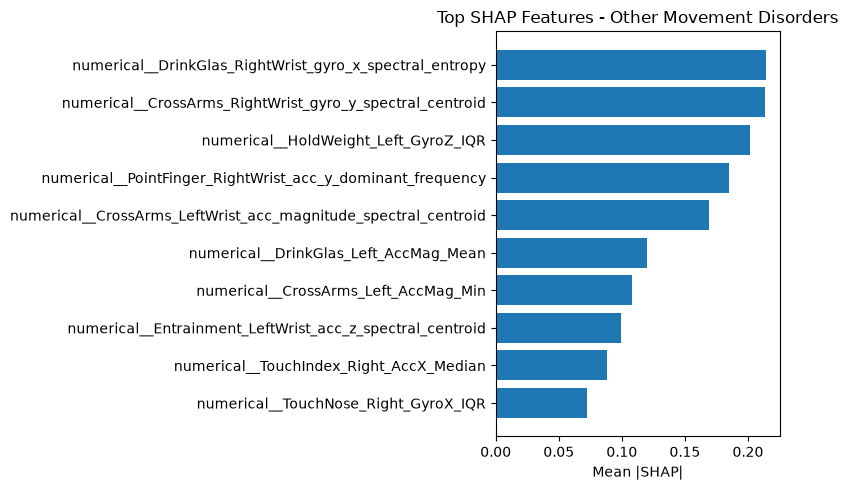

In [15]:
for class_idx in range(len(CLASS_NAMES)):
    top = class_importance[class_idx].head(10)
    plt.figure(figsize=(8,5))
    plt.barh(
        top["Feature"][::-1],
        top["Mean |SHAP|"][::-1]
    )
    plt.title(
        f"Top SHAP Features - {CLASS_NAMES[class_idx]}"
    )
    plt.xlabel("Mean |SHAP|")
    plt.tight_layout()
    plt.show()

In [16]:
# Save class-specific SHAP tables
for class_idx in range(len(CLASS_NAMES)):
    safe_name = (
        CLASS_NAMES[class_idx]
        .replace(" ", "_")
        .replace("'", "")
    )
    output_path = (
        SHAP_TABLES
        / f"shap_importance_{safe_name}.csv"
    )
    class_importance[class_idx].to_csv(
        output_path,
        index=False
    )
    print(f"Saved: {output_path}")

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_importance_Healthy.csv
Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_importance_Parkinsons_Disease.csv
Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_importance_Other_Movement_Disorders.csv


### Observation

Class-specific SHAP analysis demonstrated that the relative importance of questionnaire and wearable features differed across the three diagnostic groups.

For the **Healthy** class, predictions were driven primarily by the aggregated **gastrointestinal symptom count**, followed by wearable features extracted from the Stretch Hold, Relaxed Task, and Hold Weight assessments. Questionnaire-derived variables, including **Q25** and the **cardiovascular symptom count**, also contributed substantially to healthy classifications.

For **Parkinson's Disease**, questionnaire-derived variables remained highly influential. The aggregated **urinary symptom count** and **distortion/perception symptom count** were the two most important predictors, followed by questionnaire item **Q02**. Wearable features extracted from the Relaxed Task, Touch Nose, Stretch Hold, and Lift Hold assessments also played an important role in distinguishing Parkinson's disease cases.

In contrast, predictions for **Other Movement Disorders** relied predominantly on wearable sensor features. Spectral and time-domain characteristics extracted during the Drink Glass, Cross Arms, Hold Weight, Point Finger, and Entrainment tasks were among the strongest contributors, whereas questionnaire-derived variables were considerably less prominent.

Overall, these findings indicate that the final XGBoost model integrates complementary information from both clinical questionnaires and wearable sensor recordings. Questionnaire-derived symptom domains contributed most strongly to distinguishing Healthy participants and Parkinson's disease cases, while movement-derived features became increasingly important for differentiating Other Movement Disorders.

## SHAP Importance by Modality

The previous analysis examined feature importance at the individual predictor level. To improve interpretability, the selected features are grouped into broader data modalities.

Each selected feature is assigned to one of the following categories:

- Wearable Sensor Features
- Questionnaire Features
- Demographic Features

The mean absolute SHAP values are then aggregated within each modality to estimate the overall contribution of each data source to the predictions generated by the final XGBoost model.

In [17]:
def identify_modality(feature):
    feature = feature.lower()
    if "__q" in feature:
        return "Questionnaire"
    if "count" in feature:
        return "Questionnaire"
    if "gender" in feature:
        return "Demographics"
    if "handedness" in feature:
        return "Demographics"
    if "family_history" in feature:
        return "Demographics"
    return "Wearable Sensors"

In [18]:
importance_df["Modality"] = (
    importance_df["Feature"]
    .apply(identify_modality)
)
modality_importance = (
    importance_df
    .groupby("Modality")["Mean |SHAP|"]
    .sum()
    .reset_index()
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
)
display(modality_importance)

,Modality,Mean |SHAP|
2,Wearable Sensors,3.663672
1,Questionnaire,0.860253
0,Demographics,0.000000


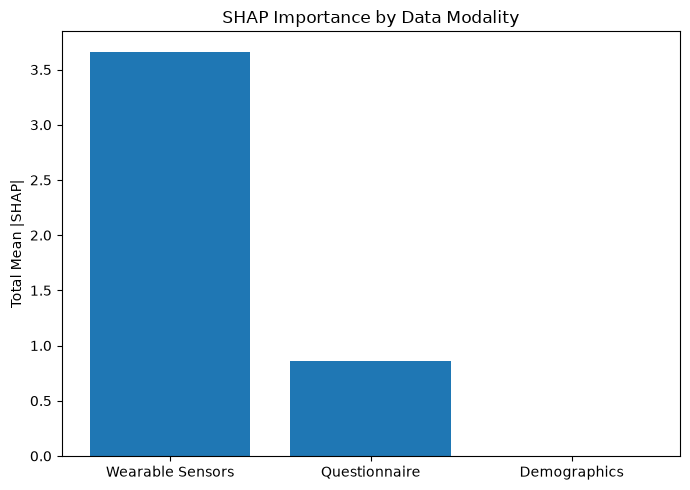

In [19]:
plt.figure(figsize=(7,5))
plt.bar(
    modality_importance["Modality"],
    modality_importance["Mean |SHAP|"]
)
plt.ylabel("Total Mean |SHAP|")
plt.title("SHAP Importance by Data Modality")
plt.tight_layout()
plt.savefig(
    SHAP_FIGURES / "shap_modality_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [20]:
modality_importance.to_csv(
    SHAP_TABLES / "shap_modality_importance.csv",
    index=False
)
print("Saved:", SHAP_TABLES / "shap_modality_importance.csv")

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_modality_importance.csv


### Observation

The aggregated SHAP analysis demonstrates that **wearable sensor features** contributed the largest share of the model's overall explanatory power, with a cumulative mean absolute SHAP value of **3.664**. This finding indicates that movement-derived characteristics extracted from the smartwatch recordings were the primary source of predictive information used by the final XGBoost model.

**Questionnaire-derived features** represented the second most influential modality, contributing a cumulative mean absolute SHAP value of **0.860**. These features included both individual questionnaire items and clinically meaningful symptom-domain aggregates, providing complementary non-motor information that enhanced the model's predictions.

In contrast, **demographic variables** showed virtually no contribution to the final predictions. Their aggregated SHAP importance was negligible, suggesting that demographic characteristics did not provide additional predictive information once wearable sensor measurements and questionnaire-derived variables were incorporated into the model.

Overall, the modality-level analysis highlights the complementary nature of the multimodal framework. While wearable sensor features provided the strongest predictive signal, questionnaire-derived variables supplied clinically relevant information that further improved model interpretability and discrimination across diagnostic classes.

## SHAP Importance by Neurological Task

To better understand which neurological assessments contributed most to the model predictions, SHAP feature importances were aggregated according to the standardized neurological task from which each wearable feature was extracted.

Questionnaire-derived and demographic variables were excluded from this analysis because they are not associated with a specific movement assessment.

This aggregation provides a higher-level interpretation of the final XGBoost model by identifying the neurological tasks that contributed most strongly to its predictions.

In [21]:
TASKS = [
    "CrossArms",
    "DrinkGlas",
    "Entrainment",
    "HoldWeight",
    "LiftHold",
    "RelaxedTask",
    "Relaxed",
    "TouchIndex",
    "TouchNose"
]

def identify_task(feature):

    for task in TASKS:
        if task.lower() in feature.lower():
            return task

    return np.nan

In [22]:
task_df = importance_df.copy()
task_df["Task"] = task_df["Feature"].apply(identify_task)
task_df = task_df.dropna(subset=["Task"])
task_importance = (
    task_df
    .groupby("Task")["Mean |SHAP|"]
    .sum()
    .reset_index()
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
)

display(task_importance)

,Task,Mean |SHAP|
3,HoldWeight,0.567397
8,TouchNose,0.560153
6,RelaxedTask,0.528101
0,CrossArms,0.408568
1,DrinkGlas,0.308099
4,LiftHold,0.285034
7,TouchIndex,0.185862
5,Relaxed,0.156640
2,Entrainment,0.057489


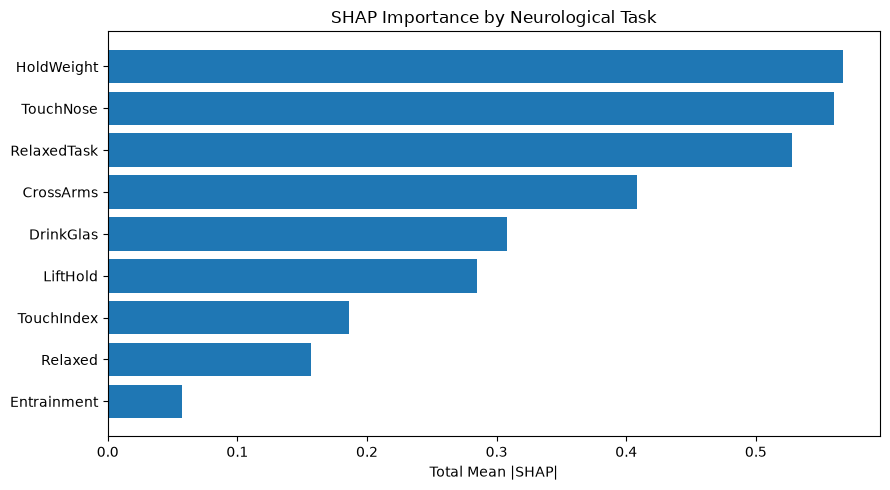

In [23]:
plt.figure(figsize=(9,5))
plt.barh(
    task_importance["Task"][::-1],
    task_importance["Mean |SHAP|"][::-1]
)
plt.xlabel("Total Mean |SHAP|")
plt.title("SHAP Importance by Neurological Task")
plt.tight_layout()
plt.savefig(
    SHAP_FIGURES /
    "shap_task_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [24]:
task_importance.to_csv(
    SHAP_TABLES /
    "shap_task_importance.csv",
    index=False
)

print(
    "Saved:",
    SHAP_TABLES /
    "shap_task_importance.csv"
)

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_task_importance.csv


### Observation

The task-level SHAP analysis indicates that the final XGBoost model relied on information extracted from multiple neurological assessments rather than a single movement task.

Among the wearable-derived features, **Hold Weight** exhibited the highest cumulative SHAP importance, closely followed by **Touch Nose** and **Relaxed Task**. These assessments contributed the largest share of movement-related information used by the model.

Additional contributions were obtained from the **Cross Arms**, **Drink Glass**, **Lift Hold**, **Touch Index**, and **Relaxed** tasks, while **Entrainment** showed the lowest overall contribution among the retained tasks.

Overall, these findings suggest that the predictive information is distributed across several standardized neurological assessments, supporting the inclusion of multiple motor tasks to capture complementary aspects of Parkinsonian motor impairment.

## SHAP Importance by Wrist

To further investigate the contribution of the wearable sensors, SHAP feature importances were grouped according to the wrist from which each feature was extracted.

Only wearable-derived variables were considered in this analysis, while questionnaire and demographic features were excluded.

The aggregated SHAP values provide an estimate of the relative contribution of the left and right wrist to the final XGBoost model.

In [25]:
def identify_wrist(feature):
    feature = feature.lower()
    if "left" in feature:
        return "Left Wrist"
    if "right" in feature:
        return "Right Wrist"
    return np.nan

In [26]:
wrist_df = importance_df.copy()
wrist_df["Wrist"] = wrist_df["Feature"].apply(
    identify_wrist
)
wrist_df = wrist_df.dropna(
    subset=["Wrist"]
)
wrist_importance = (
    wrist_df
    .groupby("Wrist")["Mean |SHAP|"]
    .sum()
    .reset_index()
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
)
display(wrist_importance)

,Wrist,Mean |SHAP|
1,Right Wrist,1.921100
0,Left Wrist,1.715998


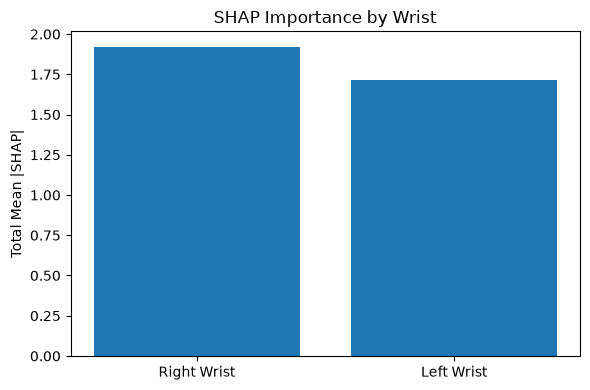

In [27]:
plt.figure(figsize=(6,4))
plt.bar(
    wrist_importance["Wrist"],
    wrist_importance["Mean |SHAP|"]
)
plt.ylabel("Total Mean |SHAP|")
plt.title(
    "SHAP Importance by Wrist"
)
plt.tight_layout()
plt.savefig(
    SHAP_FIGURES /
    "shap_wrist_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [28]:
wrist_importance.to_csv(
    SHAP_TABLES /
    "shap_wrist_importance.csv",
    index=False
)
print("Saved:", SHAP_TABLES / "shap_wrist_importance.csv")

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_wrist_importance.csv


### Observation

The wrist-level SHAP analysis showed that both wearable devices contributed substantially to the final predictions.

The **right wrist** exhibited a slightly higher cumulative SHAP importance (1.921) than the **left wrist** (1.716). Although this difference was modest, it suggests that the model extracted marginally more predictive information from movements recorded on the dominant side in many participants.

Overall, the relatively balanced contribution of both wrists indicates that bilateral wearable recordings provide complementary movement information and enhance the robustness of the multimodal screening framework.

## SHAP Importance by Sensor Type

To investigate the relative contribution of each wearable sensor, SHAP feature importances were grouped according to the sensor from which each feature was extracted.

Accelerometer-derived and gyroscope-derived features were aggregated separately, while questionnaire and demographic variables were excluded.

This analysis provides a high-level comparison of the contribution of each sensor type to the predictions generated by the final XGBoost model.

In [29]:
def identify_sensor(feature):
    feature = feature.lower()
    if "gyro" in feature:
        return "Gyroscope"
    if "acc" in feature:
        return "Accelerometer"
    return np.nan

In [30]:
sensor_df = importance_df.copy()
sensor_df["Sensor"] = sensor_df["Feature"].apply(
    identify_sensor
)
sensor_df = sensor_df.dropna(
    subset=["Sensor"]
)
sensor_importance = (
    sensor_df
    .groupby("Sensor")["Mean |SHAP|"]
    .sum()
    .reset_index()
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
)
display(sensor_importance)

,Sensor,Mean |SHAP|
0,Accelerometer,1.833649
1,Gyroscope,1.822734


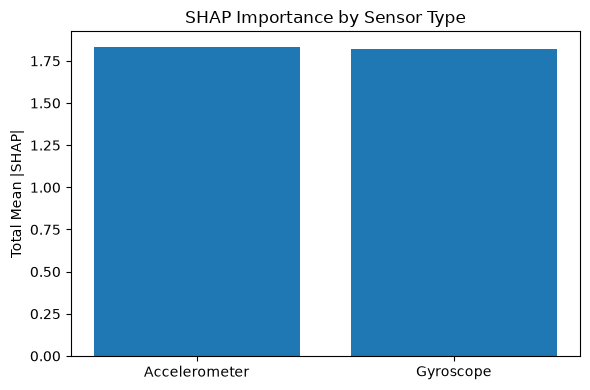

In [31]:
plt.figure(figsize=(6,4))
plt.bar(
    sensor_importance["Sensor"],
    sensor_importance["Mean |SHAP|"]
)
plt.ylabel("Total Mean |SHAP|")
plt.title("SHAP Importance by Sensor Type")
plt.tight_layout()
plt.savefig(
    SHAP_FIGURES /
    "shap_sensor_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [32]:
sensor_importance.to_csv(
    SHAP_TABLES /
    "shap_sensor_importance.csv",
    index=False
)
print(
    "Saved:",
    SHAP_TABLES /
    "shap_sensor_importance.csv"
)

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_sensor_importance.csv


### Observation

The sensor-level SHAP aggregation demonstrated that both wearable sensors contributed almost equally to the final multiclass predictions.

Features derived from the **accelerometer** exhibited a slightly higher cumulative SHAP importance (1.834) than those extracted from the **gyroscope** (1.823). However, the difference between the two sensor types was minimal.

These findings indicate that linear acceleration and angular velocity measurements provide complementary movement information. Consequently, combining both sensor modalities enables the model to capture a broader representation of motor impairment than either sensor alone.

## SHAP Importance by Questionnaire Responses

In addition to wearable-derived movement features, the final model incorporates questionnaire variables describing non-motor symptoms associated with Parkinson's disease.

This section isolates the questionnaire items retained after feature selection and summarizes their SHAP importance to identify which non-motor symptoms contributed most strongly to the final predictions.

In [33]:
questionnaire_df = (
    importance_df[
        importance_df["Feature"]
        .str.contains(
            r"__Q\d+",
            regex=True
        )
    ]
    .copy()
)
display(questionnaire_df)

,Feature,Mean |SHAP|,Modality
4,numerical__Q25,0.119215,Questionnaire
7,numerical__Q02,0.080700,Questionnaire
92,numerical__Q01,0.012215,Questionnaire
97,numerical__Q08,0.011869,Questionnaire
173,numerical__Q22,0.005017,Questionnaire
274,numerical__Q05,0.001563,Questionnaire
305,numerical__Q09,0.000779,Questionnaire
308,numerical__Q26,0.000731,Questionnaire
351,numerical__Q15,0.000123,Questionnaire
354,numerical__Q27,0.000000,Questionnaire


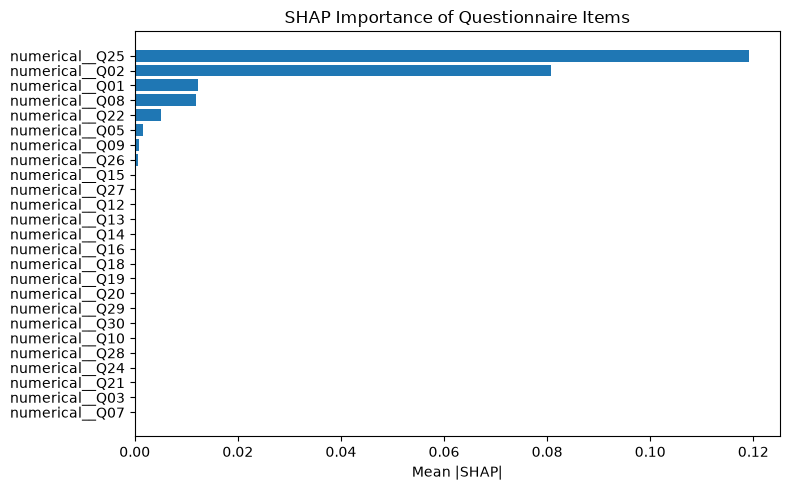

In [34]:
top_questionnaire = (
    questionnaire_df
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
)
plt.figure(figsize=(8,5))
plt.barh(
    top_questionnaire["Feature"][::-1],
    top_questionnaire["Mean |SHAP|"][::-1]
)
plt.xlabel("Mean |SHAP|")
plt.title(
    "SHAP Importance of Questionnaire Items"
)

plt.tight_layout()
plt.savefig(
    SHAP_FIGURES /
    "shap_questionnaire_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [35]:
questionnaire_labels = {
    "Q01": "Dribbling of saliva during the daytime",
    "Q02": "Loss or change in the ability to taste or smell",
    "Q03": "Difficulty swallowing food or drink",
    "Q04": "Vomiting or feelings of sickness (nausea)",
    "Q05": "Constipation or straining during bowel movements",
    "Q06": "Bowel (fecal) incontinence",
    "Q07": "Feeling of incomplete bowel emptying",
    "Q08": "Urinary urgency",
    "Q09": "Frequently getting up at night to urinate",
    "Q10": "Unexplained pain",
    "Q11": "Unexplained change in weight",
    "Q12": "Problems remembering recent events",
    "Q13": "Loss of interest in activities",
    "Q14": "Seeing or hearing things that are not there",
    "Q15": "Difficulty concentrating",
    "Q16": "Feeling sad or low",
    "Q17": "Feeling anxious or frightened",
    "Q18": "Changes in sexual interest",
    "Q19": "Difficulty having sex",
    "Q20": "Light-headedness when standing",
    "Q21": "Falling",
    "Q22": "Difficulty staying awake during activities",
    "Q23": "Difficulty falling or staying asleep",
    "Q24": "Intense or vivid dreams",
    "Q25": "Talking or moving during sleep as if acting out a dream",
    "Q26": "Unpleasant leg sensations at rest",
    "Q27": "Swelling of the legs",
    "Q28": "Excessive sweating",
    "Q29": "Double vision",
    "Q30": "Believing things that others say are not true"
}

questionnaire_table = top_questionnaire.copy()

questionnaire_table["Item"] = (
    questionnaire_table["Feature"]
    .str.extract(r"(Q\d+)")
)

questionnaire_table["Questionnaire Response"] = (
    questionnaire_table["Item"]
    .map(questionnaire_labels)
)

questionnaire_table = questionnaire_table[
    [
        "Item",
        "Questionnaire Response",
        "Mean |SHAP|"
    ]
]

questionnaire_table.insert(
    0,
    "Rank",
    range(1, len(questionnaire_table)+1)
)

questionnaire_table["Mean |SHAP|"] = (
    questionnaire_table["Mean |SHAP|"]
    .round(4)
)

display(questionnaire_table)

,Rank,Item,Questionnaire Response,Mean |SHAP|
4,1,Q25,Talking or moving during sleep as if acting ou...,0.1192
7,2,Q02,Loss or change in the ability to taste or smell,0.0807
92,3,Q01,Dribbling of saliva during the daytime,0.0122
97,4,Q08,Urinary urgency,0.0119
173,5,Q22,Difficulty staying awake during activities,0.0050
274,6,Q05,Constipation or straining during bowel movements,0.0016
305,7,Q09,Frequently getting up at night to urinate,0.0008
308,8,Q26,Unpleasant leg sensations at rest,0.0007
351,9,Q15,Difficulty concentrating,0.0001
354,10,Q27,Swelling of the legs,0.0000


In [36]:
top_questionnaire.to_csv(
    SHAP_TABLES /
    "shap_questionnaire_importance.csv",
    index=False
)
questionnaire_table.to_csv(
    SHAP_TABLES / "questionnaire_shap_summary.csv",
    index=False
)
print(
    "Saved:",
    SHAP_TABLES /
    "shap_questionnaire_importance.csv"
)
print(
    "Saved:",
    SHAP_TABLES /
    "questionnaire_shap_summary.csv"
)

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_questionnaire_importance.csv
Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\questionnaire_shap_summary.csv


### Observation

Although numerous questionnaire items were retained after feature selection, only a small subset contributed meaningfully to the final XGBoost model.

The most influential questionnaire responses were **Q25 (Talking or moving during sleep as if acting out a dream)** and **Q02 (Loss or change in the ability to taste or smell)**, followed by **Q01 (Dribbling of saliva during the daytime)**, **Q08 (Urinary urgency)**, and **Q22 (Difficulty staying awake during activities)**.

Most of the remaining questionnaire items exhibited SHAP values close to zero, indicating that they contributed minimally once wearable sensor features and questionnaire-derived symptom-domain aggregates were incorporated into the model.

Overall, these findings suggest that the predictive value of the questionnaire is concentrated in a limited number of clinically relevant non-motor symptoms, while wearable sensor measurements provide the majority of the discriminative information used by the final multimodal model.

# 2. Local SHAP Explanations

Global SHAP analysis identifies the features that are important across the entire test dataset. However, clinical decision support also requires understanding why the model generated a prediction for an individual participant.

This section presents participant-level explanations using the final **Full Multimodal XGBoost** classifier. Three correctly classified participants, one from each diagnostic class, are selected to illustrate how wearable-derived movement features and questionnaire variables contribute to individualized predictions.

For each participant, the following information is presented:

- True diagnosis
- Predicted diagnosis
- Prediction probabilities
- Local SHAP explanation
- Features supporting the prediction
- Features opposing the prediction

In [37]:
# Setup
classifier = pipeline.named_steps["classifier"]
classes = classifier.classes_
CLASS_NAMES = {
    0: "Healthy",
    1: "Parkinson's Disease",
    2: "Other Movement Disorders"
}
y_true = test_df["label"]
predictions = classifier.predict(X_processed)
prediction_probabilities = classifier.predict_proba(X_processed)
results_df = pd.DataFrame({
    "Participant":test_df["patient_id"],
    "True Class":y_true,
    "Predicted Class":predictions,
    "Confidence":prediction_probabilities.max(axis=1)
})
display(results_df.head())

,Participant,True Class,Predicted Class,Confidence
0,18,2,1,0.904193
1,25,1,1,0.991225
2,28,1,1,0.630845
3,43,2,1,0.678255
4,51,1,2,0.654599


In [38]:
examples = {}
for c in classes:
    idx = results_df[
        (results_df["True Class"]==c) &
        (results_df["Predicted Class"]==c)
    ].index[0]
    examples[c]=idx
example_summary=[]
for c,idx in examples.items():
    probs=prediction_probabilities[idx]
    example_summary.append({
        "Participant":
        results_df.loc[idx,"Participant"],
        "True Class":
        CLASS_NAMES[c],
        "Predicted Class":
        CLASS_NAMES[
            results_df.loc[idx,"Predicted Class"]
        ],
        "Predicted Probability":
        round(np.max(probs),3)
    })
example_summary=pd.DataFrame(example_summary)
display(example_summary)

,Participant,True Class,Predicted Class,Predicted Probability
0,160,Healthy,Healthy,0.661
1,25,Parkinson's Disease,Parkinson's Disease,0.991
2,66,Other Movement Disorders,Other Movement Disorders,0.963


### Observation

One correctly classified participant from each diagnostic class was selected to illustrate participant-level explanations. These examples demonstrate how the final XGBoost model integrates wearable sensor measurements and questionnaire-derived information when generating individualized predictions.
The selected participants are representative examples intended to illustrate the model's decision-making process rather than the highest-confidence predictions observed in the test dataset.

In [43]:
def explain_participant(idx):

    print("=" * 70)

    patient = results_df.loc[idx, "Participant"]

    true_class = results_df.loc[idx, "True Class"]

    predicted_class = results_df.loc[idx, "Predicted Class"]

    print("Participant:", patient)
    print("True class:", CLASS_NAMES[true_class])
    print("Predicted:", CLASS_NAMES[predicted_class])

    # ==========================================================
    # Prediction probabilities
    # ==========================================================

    probs = prediction_probabilities[idx]

    prob_df = pd.DataFrame({
        "Class": [CLASS_NAMES[c] for c in classes],
        "Probability": np.round(probs, 4)
    })

    display(prob_df)

    # ==========================================================
    # SHAP values
    # ==========================================================

    predicted_idx = np.argmax(probs)

    local_values = shap_values[
        idx,
        :,
        predicted_idx
    ]

    local_df = pd.DataFrame({
        "Feature": selected_features,
        "SHAP": local_values
    })

    local_df["Absolute"] = local_df["SHAP"].abs()

    local_df = (
        local_df
        .sort_values(
            "Absolute",
            ascending=False
        )
    )

    display(local_df.head(10))

    # ==========================================================
    # Waterfall Plot
    # ==========================================================

    explanation = shap.Explanation(
        values=local_values,
        base_values=explainer.expected_value[predicted_idx],
        data=X_processed.iloc[idx].values,
        feature_names=selected_features
    )

    shap.plots.waterfall(
        explanation,
        max_display=15,
        show=False
    )

    fig = plt.gcf()
    fig.set_size_inches(12, 8)

    plt.tight_layout()

    class_name = (
        CLASS_NAMES[predicted_idx]
        .replace(" ", "_")
        .replace("'", "")
    )

    plt.savefig(
        SHAP_FIGURES /
        f"waterfall_{class_name}_patient_{patient}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(fig)

Participant: 160
True class: Healthy
Predicted: Healthy


,Class,Probability
0,Healthy,0.6615
1,Parkinson's Disease,0.2945
2,Other Movement Disorders,0.0440


,Feature,SHAP,Absolute
368,numerical__RelaxedTask_LeftWrist_acc_magnitude...,0.774713,0.774713
485,numerical__gastrointestinal_count,0.734587,0.734587
62,numerical__StretchHold_Left_AccZ_IQR,0.384275,0.384275
328,numerical__HoldWeight_RightWrist_gyro_y_domina...,0.191424,0.191424
408,numerical__Relaxed_RightWrist_gyro_z_spectral_...,-0.139911,0.139911
71,numerical__TouchNose_Right_GyroX_Median,-0.138060,0.138060
13,numerical__LiftHold_Right_AccX_IQR,0.130556,0.130556
479,numerical__Q25,0.126484,0.126484
415,numerical__StretchHold_RightWrist_acc_x_domina...,-0.122931,0.122931
333,numerical__LiftHold_LeftWrist_acc_x_dominant_f...,0.111147,0.111147


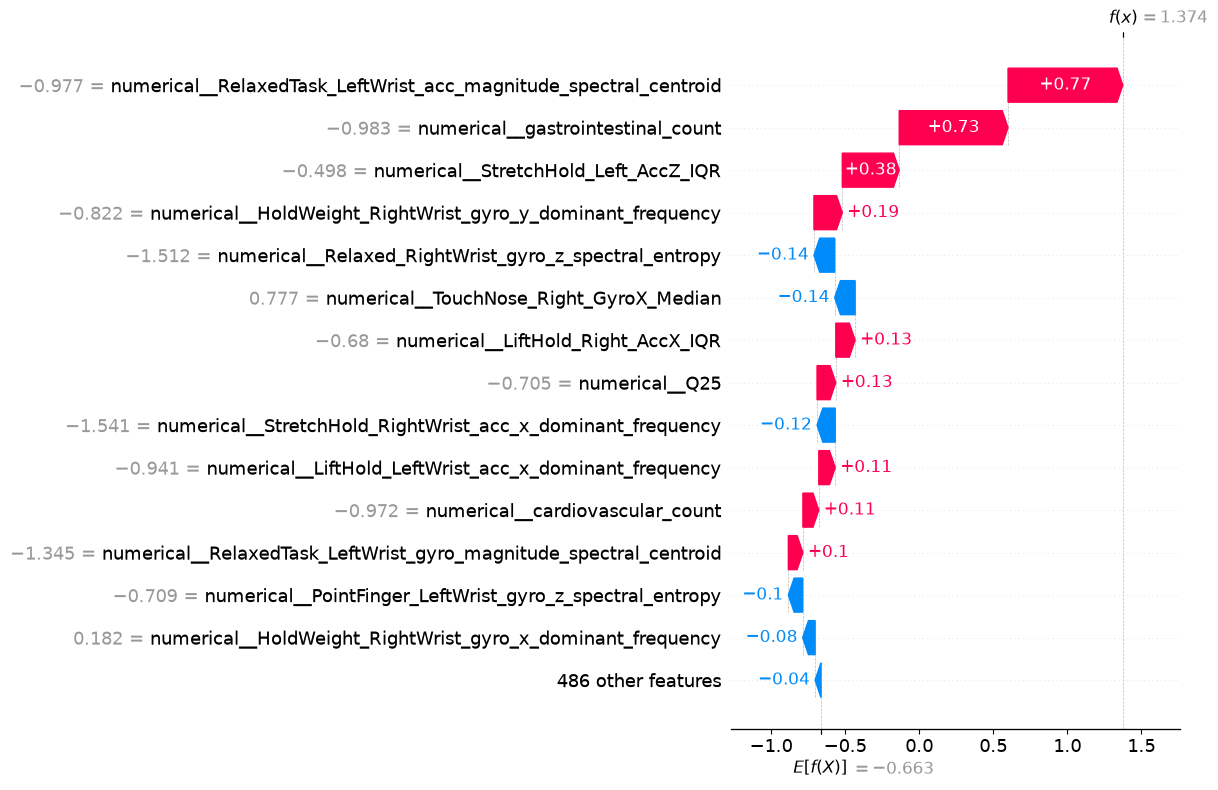

In [44]:
explain_participant(
    examples[0]
)

Participant: 25
True class: Parkinson's Disease
Predicted: Parkinson's Disease


,Class,Probability
0,Healthy,0.0031
1,Parkinson's Disease,0.9912
2,Other Movement Disorders,0.0057


,Feature,SHAP,Absolute
490,numerical__distortion_perception_count,0.626146,0.626146
486,numerical__urinary_count,0.390464,0.390464
45,numerical__TouchNose_Left_AccZ_Median,0.258700,0.258700
103,numerical__TouchNose_Left_GyroY_Median,-0.199291,0.199291
461,numerical__Q02,-0.162443,0.162443
479,numerical__Q25,0.159521,0.159521
381,numerical__RelaxedTask_RightWrist_acc_y_spectr...,0.141178,0.141178
335,numerical__LiftHold_LeftWrist_acc_x_spectral_e...,0.101694,0.101694
418,numerical__StretchHold_RightWrist_acc_y_domina...,-0.074698,0.074698
156,numerical__TouchNose_Right_GyroZ_IQR,0.059224,0.059224


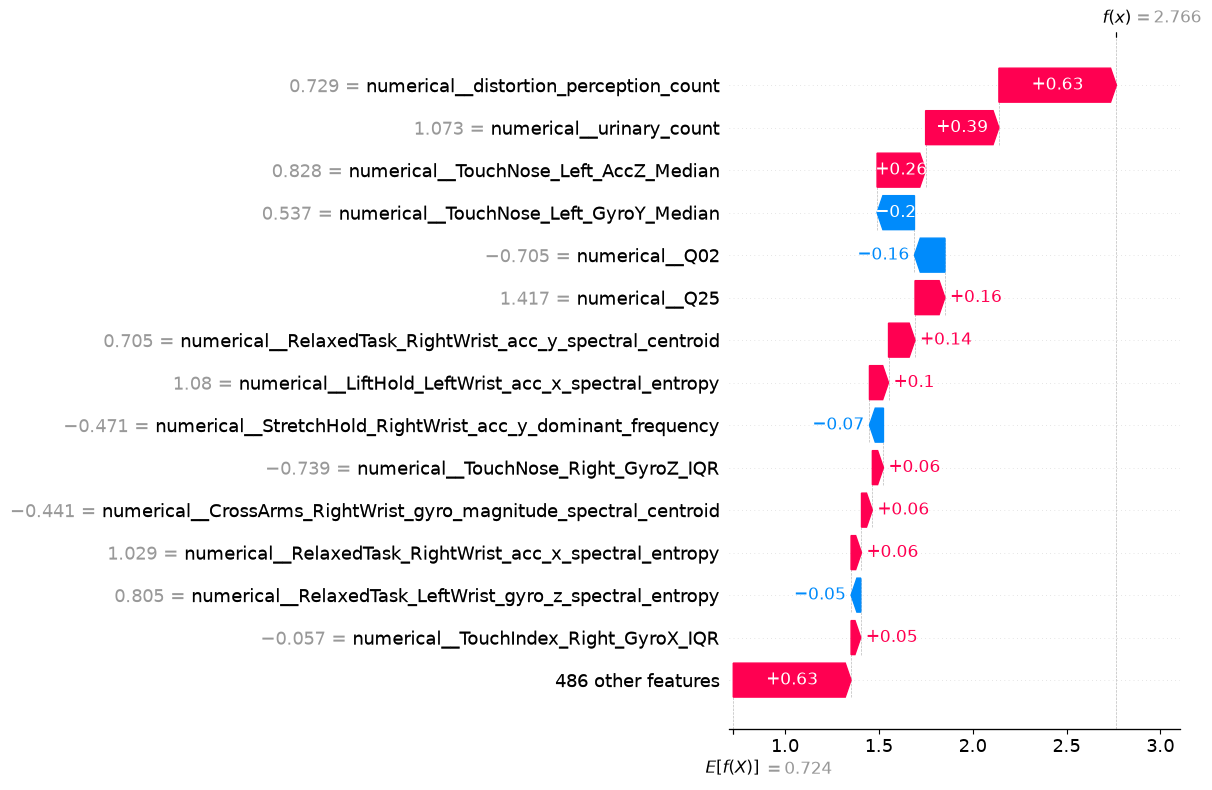

In [45]:
explain_participant(
    examples[1]
)

Participant: 66
True class: Other Movement Disorders
Predicted: Other Movement Disorders


,Class,Probability
0,Healthy,0.0103
1,Parkinson's Disease,0.0270
2,Other Movement Disorders,0.9627


,Feature,SHAP,Absolute
297,numerical__Entrainment_LeftWrist_acc_z_spectra...,-0.453941,0.453941
148,numerical__HoldWeight_Left_GyroZ_IQR,0.448602,0.448602
207,numerical__TouchNose_Right_GyroMag_Median,-0.332814,0.332814
246,numerical__CrossArms_LeftWrist_acc_magnitude_s...,0.296904,0.296904
365,numerical__PointFinger_RightWrist_acc_y_domina...,0.245537,0.245537
293,numerical__DrinkGlas_RightWrist_gyro_x_spectra...,0.218678,0.218678
271,numerical__CrossArms_RightWrist_gyro_y_spectra...,0.175403,0.175403
322,numerical__HoldWeight_RightWrist_acc_z_spectra...,0.163289,0.163289
47,numerical__DrinkGlas_Left_AccZ_Std,0.136191,0.136191
144,numerical__DrinkGlas_Left_GyroZ_Range,0.114697,0.114697


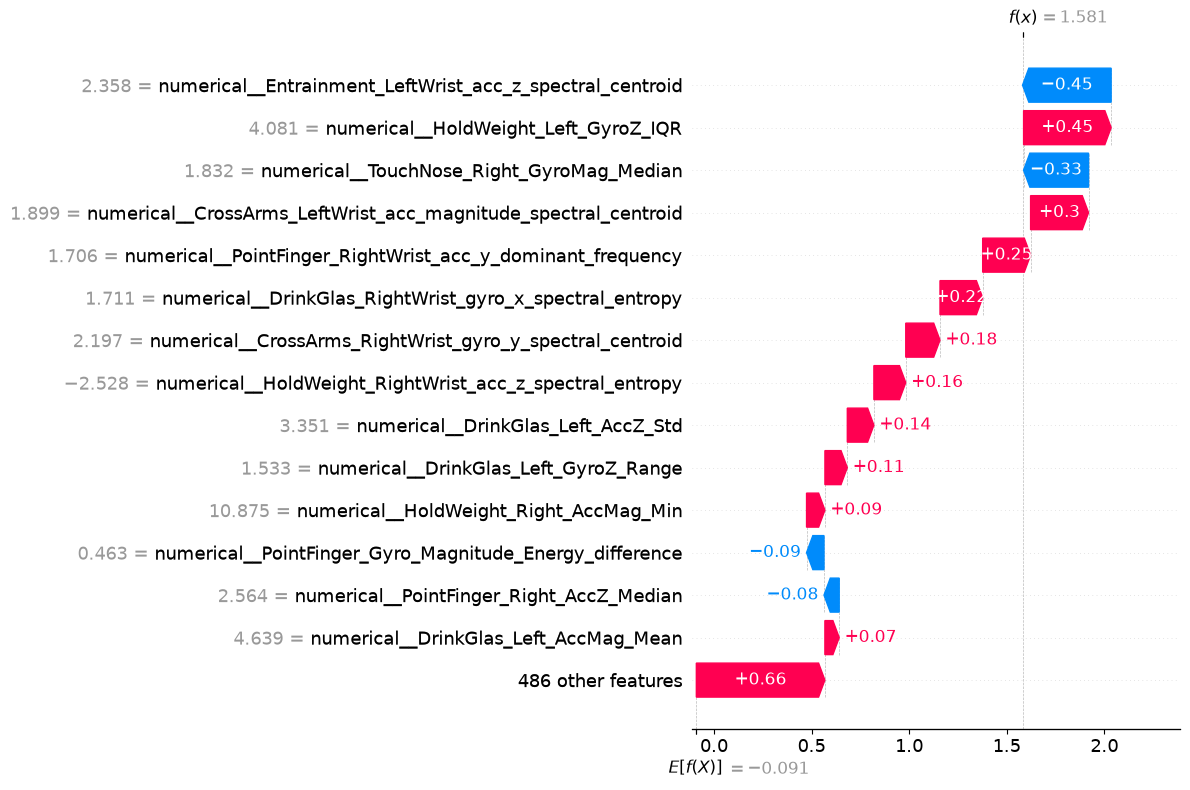

In [46]:
explain_participant(
    examples[2]
)

### Discussion

The local SHAP explanations were consistent with the global feature importance analysis.

For the **Healthy** participant, the prediction was primarily supported by a combination of wearable-derived movement features and questionnaire-derived variables, particularly the **gastrointestinal symptom count** and **Q25 (REM sleep behavior symptoms)**, together with movement characteristics extracted from the Relaxed Task, Stretch Hold, and Hold Weight assessments.

For the **Parkinson's Disease** participant, the strongest positive contributions originated from the aggregated **distortion/perception symptom count** and **urinary symptom count**, accompanied by wearable features extracted from the Touch Nose and Relaxed Task assessments. Questionnaire items **Q25** and **Q02** also contributed to the final prediction.

In contrast, the participant classified as **Other Movement Disorders** was characterized almost entirely by wearable-derived movement features extracted from several neurological tasks, including Entrainment, Hold Weight, Touch Nose, Cross Arms, Point Finger, and Drink Glass. Questionnaire variables contributed comparatively little to this prediction.

Overall, these participant-level explanations demonstrate that the final XGBoost model integrates complementary questionnaire-derived and movement-derived information, while allowing the relative contribution of each modality to vary according to the clinical characteristics of the individual participant.

## Summary of SHAP Findings

The SHAP analysis provides a comprehensive interpretation of the final **XGBoost** classifier by identifying both globally important predictors and participant-specific decision patterns.

Across all analyses, **wearable sensor features** contributed the greatest overall explanatory power, while **questionnaire-derived variables** provided complementary clinical information and **demographic variables** contributed negligibly to the final predictions.

Among the neurological assessments, the **Hold Weight**, **Touch Nose**, and **Relaxed Task** evaluations exhibited the highest cumulative SHAP importance, indicating that these tasks capture highly discriminative movement characteristics for distinguishing Healthy participants, Parkinson's Disease, and Other Movement Disorders.

Both wrists contributed substantially to the model, with a slight predominance of the **right wrist**, while accelerometer- and gyroscope-derived features exhibited nearly identical cumulative importance, highlighting the complementary value of both sensing modalities.

Within the questionnaire, the most influential individual items included **Q25 (REM sleep behavior symptoms)**, **Q02 (loss or change in smell or taste)**, **Q01 (daytime drooling)**, **Q08 (urinary urgency)**, and **Q22 (difficulty staying awake during activities)**. At the global level, aggregated symptom-domain variables such as **gastrointestinal**, **urinary**, and **distortion/perception** symptom counts emerged among the strongest clinical predictors.

Finally, local SHAP explanations demonstrated that individual predictions are generated through different combinations of wearable-derived movement characteristics and clinically relevant non-motor symptoms rather than relying on any single dominant predictor, providing transparent and clinically interpretable explanations for each participant.

## Limitations

Although SHAP provides valuable insight into feature importance and individual predictions, several limitations should be considered.

First, SHAP explanations reflect the behavior of the trained **XGBoost** model rather than establishing causal relationships between clinical variables and disease status. Features identified as highly important should therefore be interpreted as influential for the model's predictions rather than definitive clinical biomarkers.

Second, feature importance was computed after preprocessing and feature selection. Consequently, the explanations are restricted to the **500 selected features** retained by the final modeling pipeline and do not represent the complete set of original wearable, questionnaire, and demographic variables.

Finally, local explanations describe the reasoning behind individual predictions and may vary across participants. Therefore, participant-level SHAP explanations should always be interpreted together with the global importance analysis to obtain a comprehensive understanding of the model's behavior.